In [4]:
from astropy import units as u
import matplotlib.pyplot as plt

def fermi_lat_psf_quantity(E):
    """
    Like fermi_lat_psf, but takes/returns an Astropy Quantity.

    Parameters
    ----------
    E : astropy.units.Quantity
        Photon energy (e.g. in MeV or GeV).

    Returns
    -------
    psf : astropy.units.Quantity
        PSF in degrees.
    """
    E = E.to(u.MeV)
    psf = 3.5 * (E / (100 * u.MeV))**(-0.8) * u.deg
    return psf

# Example with units
if __name__ == "__main__":
    Eq = [50, 100, 1000, 5000, 10000, 50000, 100000, 200000] * u.MeV
    psf_values = fermi_lat_psf_quantity(Eq)
    for e in Eq:
        print(f"Energy: {e}, PSF: {fermi_lat_psf_quantity(e)}")
    #

Energy: 50.0 MeV, PSF: 6.093853943072869 deg
Energy: 100.0 MeV, PSF: 3.5 deg
Energy: 1000.0 MeV, PSF: 0.5547126173613897 deg
Energy: 5000.0 MeV, PSF: 0.1530706903520589 deg
Energy: 10000.0 MeV, PSF: 0.08791602510283528 deg
Energy: 50000.0 MeV, PSF: 0.024260069510430117 deg
Energy: 100000.0 MeV, PSF: 0.0139337509693724 deg
Energy: 200000.0 MeV, PSF: 0.00800283840872821 deg


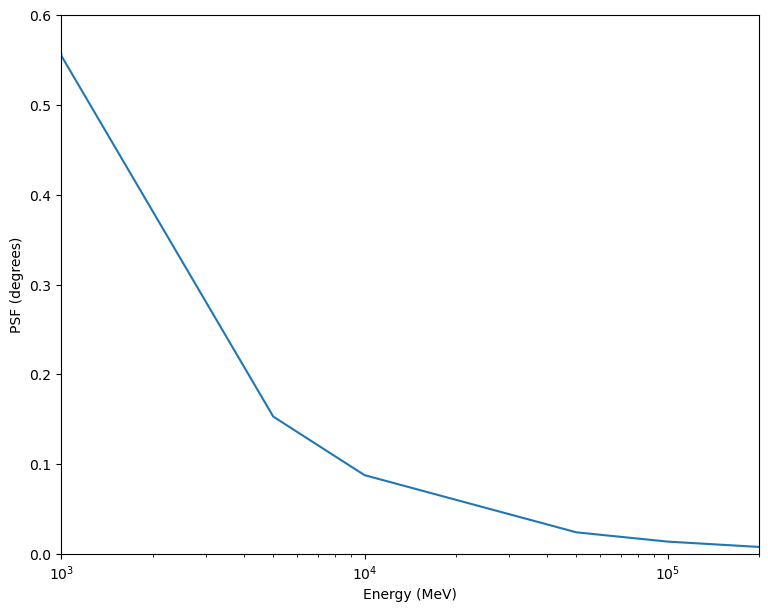

In [22]:
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(9, 7))    
plt.plot(Eq, psf_values)

plt.xlabel("Energy (MeV)")
plt.ylabel("PSF (degrees)")

plt.xscale("log")
plt.ylim(0,0.6)
plt.xlim(1000,200000)
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.get_major_formatter().set_scientific(False)

In [ ]:
from astropy.io import fits  # FITS handling  [oai_citation:5‡Astropy](https://docs.astropy.org/en/stable/io/fits/index.html?utm_source=chatgpt.com)

def load_psf_quartile_tables(fits_path, memmap=True):
    """
    Load RPSF, scaling params, and fisheye tables for PSF0–PSF3.

    Parameters
    ----------
    fits_path : str
        Path to 'psf_P8R3_SOURCE_V3_PSF.fits' (local or URL).
    memmap : bool
        Whether to memory-map the file (saves RAM on large tables).

    Returns
    -------
    psf_tables : dict
        A dict keyed by quartile string 'PSF0'...'PSF3', each mapping to a
        sub-dict with keys 'rpsf', 'scale', 'fisheye' holding the HDU.data
        structured arrays.
    """
    # Open the FITS file (supports URLs & caching)  [oai_citation:6‡Stack Overflow](https://stackoverflow.com/questions/32643206/how-do-i-open-a-fits-file-from-a-url-in-astropy?utm_source=chatgpt.com)
    hdul = fits.open(fits_path, memmap=memmap)

    # Print summary of HDUs if you like:
    # hdul.info()  # Shows all extensions by name & index  [oai_citation:7‡Astropy](https://docs.astropy.org/en/stable/io/fits/api/files.html?utm_source=chatgpt.com)

    psf_tables = {}
    for q in range(4):
        key = f"PSF{q}"
        # Construct extension names
        rpsf_name   = f"RPSF_PSF{q}"
        scale_name  = f"PSF_SCALING_PARAMS_PSF{q}"
        fisheye_name= f"FISHEYE_CORRECTION_PSF{q}"

        # Access each BinTableHDU by name  [oai_citation:8‡Astropy](https://docs.astropy.org/en/stable/io/fits/index.html?utm_source=chatgpt.com)
        rpsf_hdu    = hdul[rpsf_name]
        scale_hdu   = hdul[scale_name]
        fisheye_hdu = hdul[fisheye_name]

        # Extract the structured arrays
        psf_tables[key] = {
            "rpsf"    : rpsf_hdu.data,    # e.g. energy-dependent PSF curves
            "scale"   : scale_hdu.data,   # scaling params c0, c1, beta
            "fisheye" : fisheye_hdu.data  # fisheye correction tables
        }

    hdul.close()  # Clean up file handle
    return psf_tables

# Example usage:
if __name__ == "__main__":
    fits_file = "/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits"
    tables = load_psf_quartile_tables(fits_file)
    # Now tables['PSF2']['scale'] is the scaling params for PSF2, etc.

In [104]:
fits_file = "/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits"
with fits.open(fits_file) as hdu:
    print(hdu.info())

Filename: /Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  RPSF_PSF0     1 BinTableHDU     79   1R x 10C   [23E, 23E, 8E, 8E, 184E, 184E, 184E, 184E, 184E, 184E]   
  2  PSF_SCALING_PARAMS_PSF0    1 BinTableHDU     39   1R x 1C   [3E]   
  3  FISHEYE_CORRECTION_PSF0    1 BinTableHDU     67   1R x 7C   [46E, 46E, 16E, 16E, 736E, 736E, 736E]   
  4  RPSF_PSF1     1 BinTableHDU     79   1R x 10C   [23E, 23E, 8E, 8E, 184E, 184E, 184E, 184E, 184E, 184E]   
  5  PSF_SCALING_PARAMS_PSF1    1 BinTableHDU     39   1R x 1C   [3E]   
  6  FISHEYE_CORRECTION_PSF1    1 BinTableHDU     67   1R x 7C   [46E, 46E, 16E, 16E, 736E, 736E, 736E]   
  7  RPSF_PSF2     1 BinTableHDU     79   1R x 10C   [23E, 23E, 8E, 8E, 184E, 184E, 184E, 184E, 184E, 184E]   
  8  PSF_SCALING_PARAMS_PSF2    1 BinTableHDU     39   1R x 1C   [3E] 

In [78]:
# fermi_psf.py

import os
from astropy.io import fits
import numpy as np
import astropy.units as u

def load_psf_quartile_tables(irf_fits_path):
    """
    Read the PSF FITS file and return a dict of quartile tables:
      {
        'PSF0': {'rpsf': ..., 'scale': ..., 'fisheye': ...},
        'PSF1': { … },
        ...
      }
    """
    hdul = fits.open(irf_fits_path)
    quartiles = {}
    # Each quartile has 3 HDUs: RPSF_PSFn, PSF_SCALING_PARAMS_PSFn, FISHEYE_CORRECTION_PSFn
    for q in range(4):
        tag = f'PSF{q}'
        rpsf = hdul[f'RPSF_{tag}'].data
        scale = hdul[f'PSF_SCALING_PARAMS_{tag}'].data
        fisheye = hdul[f'FISHEYE_CORRECTION_{tag}'].data
        quartiles[tag] = {
            'rpsf': rpsf,
            'scale': scale,
            'fisheye': fisheye
        }
    hdul.close()
    return quartiles

def load_psf_params_from_scaling(irf_fits_path, quartile):
    """
    Return the c0, c1, beta parameters for the given PSF quartile.
    
    Parameters
    ----------
    irf_fits_path : str
        Path to the PSF FITS (e.g. psf_P8R3_SOURCE_V3_PSF.fits).
    quartile : str
        One of 'PSF0', 'PSF1', 'PSF2', 'PSF3'.
    
    Returns
    -------
    c0, c1, beta : astropy.Quantity, astropy.Quantity, float
    """
    tables = load_psf_quartile_tables(irf_fits_path)
    if quartile not in tables:
        raise ValueError(f"Invalid quartile '{quartile}'; must be PSF0–PSF3")
    # The 'scale' table has a single row with PSFSCALE = [c0, c1, beta]
    psf_scale = tables[quartile]['scale']['PSFSCALE'][0]
    c0 = psf_scale[0] * u.rad        # core term at reference energy
    c1 = psf_scale[1] * u.rad        # asymptotic floor
    beta = float(psf_scale[2])       # power‐law index
    return c0, c1, beta

def compute_r68(energy, c0, c1, beta, e0=100*u.MeV):
    """
    Compute R68 = sqrt[ (c0*(E/E0)^(-beta))^2 + c1^2 ].
    """
    E = energy.to(e0.unit)
    core = c0 * (E / e0)**(beta)
    return np.sqrt(core**2 + c1**2)

### PSF0

In [128]:
psf_params = load_psf_params_from_scaling(
    "/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits", 
    "PSF0")
np.rad2deg(compute_r68(3000*u.MeV, psf_params[0], psf_params[1], psf_params[2]))

<Quantity 0.6629459 deg>

### PSF1

In [129]:
psf_params = load_psf_params_from_scaling(
    "/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits", 
    "PSF1")
np.rad2deg(compute_r68(3000*u.MeV, psf_params[0], psf_params[1], psf_params[2]))

<Quantity 0.37753466 deg>

### PSF2

In [130]:
psf_params = load_psf_params_from_scaling(
    "/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits", 
    "PSF2")
np.rad2deg(compute_r68(3000*u.MeV, psf_params[0], psf_params[1], psf_params[2]))

<Quantity 0.27171201 deg>

### PSF3

In [131]:
psf_params = load_psf_params_from_scaling(
    "/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits", 
    "PSF3")
np.rad2deg(compute_r68(3000*u.MeV, psf_params[0], psf_params[1], psf_params[2]))

<Quantity 0.19066815 deg>

### PSF for FRONT events

In [107]:
np.rad2deg(compute_r68(1000*u.MeV, 0.0638*u.rad, 0.00126*u.rad, -0.8))

<Quantity 0.58383368 deg>

### PSF for BACK events

In [108]:
np.rad2deg(compute_r68(1000*u.MeV, 0.123*u.rad, 0.00222*u.rad, -0.8))

<Quantity 1.12415385 deg>

In [111]:
psf_params = load_psf_params_from_scaling(
    "/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits", 
    "PSF0")
np.rad2deg(compute_r68(1000*u.MeV, np.rad2deg(psf_params[0]), np.rad2deg(psf_params[1]), psf_params[2]))

<Quantity 1.42722551 deg>

In [72]:
import numpy as np
import astropy.units as u
from astropy.io import fits

def read_psf_scale_coeffs(fits_file, psf_quartile):
    """
    Read the PSFSCALE coefficients (c0, c1, beta) for a given PSF quartile
    from the P8R3_SOURCE_V3 PSF FITS file, converting the angular terms
    from radians into degrees.

    Parameters
    ----------
    fits_file : str
        Path to the PSF FITS file (e.g. 'psf_P8R3_SOURCE_V3_PSF.fits').
    psf_quartile : str
        One of 'PSF0', 'PSF1', 'PSF2', 'PSF3'.

    Returns
    -------
    c0_deg : astropy.units.Quantity
        Core scale at reference energy, in degrees.
    c1_deg : astropy.units.Quantity
        Asymptotic tail floor, in degrees.
    beta : float
        Power-law index.
    """
    with fits.open(fits_file) as hdul:
        # the extension names are e.g. 'PSF_SCALING_PARAMS_PSF0', etc.
        extname = f'PSF_SCALING_PARAMS_{psf_quartile}'
        tbl = hdul[extname].data  # a FITS_rec with field 'PSFSCALE'
        # PSFSCALE array = [c0 (rad), c1 (rad), beta]
        c0_rad, c1_rad, beta = tbl['PSFSCALE'][0]

    # Convert the angles to degrees
    c0_deg = (c0_rad * u.rad).to(u.deg)
    c1_deg = (c1_rad * u.rad).to(u.deg)

    return c0_deg, c1_deg, beta


# Example usage:
if __name__ == '__main__':
    psf_file = '/Users/vdk/miniforge3/envs/fermipy/share/fermitools/data/caldb/data/glast/lat/bcf/psf/psf_P8R3_SOURCE_V3_PSF.fits'
    for q in ['PSF0','PSF1','PSF2','PSF3']:
        c0, c1, beta = read_psf_scale_coeffs(psf_file, q)
        print(f"{q}: c0 = {c0:.3f}, c1 = {c1:.3f}, beta = {beta:.3f}")

PSF0: c0 = 8.766 deg, c1 = 0.327 deg, beta = -0.800
PSF1: c0 = 5.523 deg, c1 = 0.102 deg, beta = -0.800
PSF2: c0 = 4.022 deg, c1 = 0.061 deg, beta = -0.800
PSF3: c0 = 2.848 deg, c1 = 0.035 deg, beta = -0.800


In [77]:
compute_r68(10000*u.MeV,2.848, 0.035, psf_params[2])

<Quantity 0.07964145>